In [24]:
import os
import google.genai as genai
from dotenv import load_dotenv
from pydantic import BaseModel
from PIL import Image
import IPython.display


load_dotenv()

api_key = os.getenv("GEMINI_API_KEY")

genai_client = genai.Client(api_key=api_key)

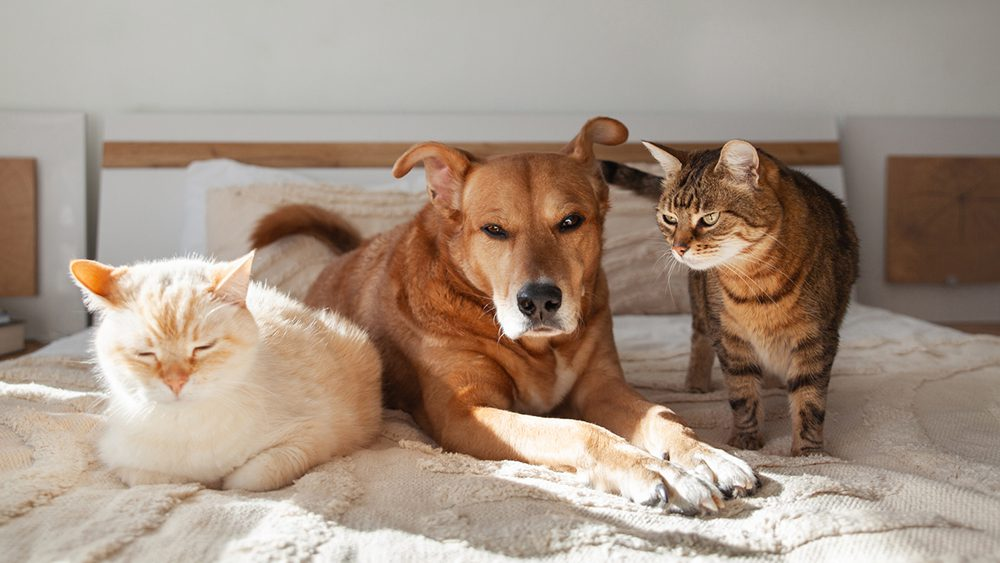

In [20]:
img_folder = "images"
images = [f for f in os.listdir(img_folder) if f.endswith(('.png', '.jpg'))]

img_path = os.path.join(img_folder, images[1])
img = Image.open(img_path)

IPython.display.display(img)

In [25]:
class ImageAnalisys(BaseModel):
    main_object: str
    detailed_desc: str
    predominat_color: list[str]
    image_feeling: str
    secodary_elements: list[str]
    likely_location: str

In [26]:
model = "gemini-2.5-flash"
contents = [
    """
    Classify the image into one of the following categories:
    - Pet
    - Bird
    - Other
    """,
    img
    ]

response = genai_client.models.generate_content(
    model=model,
    contents=contents,
    config={
        "response_mime_type": "application/json",
        "response_schema": ImageAnalisys
    }
)

print("---" * 10)
print("Response:\n", response.text)

------------------------------
Response:
 {
  "main_object": "Three pets (two cats and one dog)",
  "detailed_desc": "A light-colored cat is sleeping curled up on the left, a brown dog is lying down in the center with a serious expression, and a striped tabby cat is standing on the right, looking away. All are on a textured beige bedspread in a sunny room.",
  "predominat_color": ["brown", "beige", "white"],
  "image_feeling": "Cozy, warm, domestic, peaceful",
  "secodary_elements": ["bed", "headboard", "sunlight", "bedspread"],
  "likely_location": "Bedroom"
}
